C:\Users\restu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\restu\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\restu\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Membaca file CSV...
Berhasil! Total dimensi df_all: (44898, 5)

=== PEMERIKSAAN KUALITAS DATA ===

Jumlah nilai kosong (null) per kolom:
title      0
text       0
subject    0
date       0
label      0
dtype: int64

Jumlah baris duplikat: 209
Jumlah baris dengan teks kosong (setelah strip): 631

Info kolom dan tipe data:
<class 'pandas.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    44898 non-null  str  
 1   text     44898 non-null  str  
 2   subject  44898 non-null  str  
 3   date     44898 non-null  str  
 4   label    44898 non-null  int64
dtypes: int64(1), str(4)
memory usage: 1.7 MB
None

Distribusi label:
label
0    23481
1    21417
Name: count, dtype: int64

Dimensi df_all setelah menghapus duplikat: (44689, 5)

Sedang membersihkan seluruh data teks (Ini akan memakan waktu beberapa menit)...
Sedang melakukan vektorisasi TF-IDF...
Membagi himpunan data 80:20.

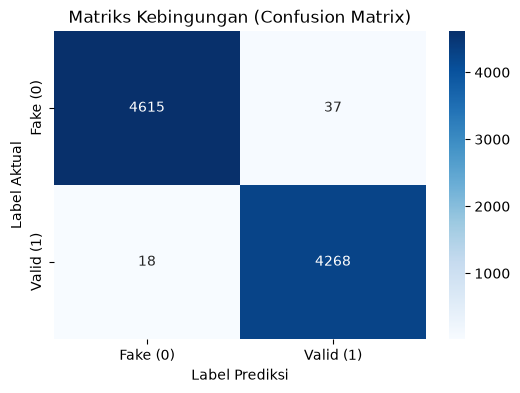

In [1]:
import kagglehub
import pandas as pd
import os
import re
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

# --- MENGUNDUH NLP TOOLS ---
nltk.download('stopwords')
nltk.download('wordnet')
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# --- DEFINISI FUNGSI CLEAN_TEXT ---
def clean_text(text):
    text = str(text).lower()  # Case Folding
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)  # Hapus URL
    text = re.sub(r'\@\w+|\#', '', text)  # Hapus mention dan hashtag
    text = re.sub(r'[^\w\s]', '', text)  # Hapus tanda baca
    tokens = text.split()  # Tokenisasi
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]  # Stopword removal & Lemmatization
    return " ".join(tokens)

# --- MENGUNDUH DAN MEMBACA DATASET ---
path = kagglehub.dataset_download("clmentbisaillon/fake-and-real-news-dataset")
fake_path = os.path.join(path, "Fake.csv")
true_path = os.path.join(path, "True.csv")

print("Membaca file CSV...")
df_fake = pd.read_csv(fake_path)
df_true = pd.read_csv(true_path)

df_fake['label'] = 0  # Label 0 untuk Berita Palsu
df_true['label'] = 1  # Label 1 untuk Berita Valid

df_all = pd.concat([df_fake, df_true], ignore_index=True)
df_all = df_all.sample(frac=1, random_state=42).reset_index(drop=True)
print("Berhasil! Total dimensi df_all:", df_all.shape)

# --- 0. PEMERIKSAAN KUALITAS DATA (untuk BAB 4.1: null, duplikat, error) ---
print("\n=== PEMERIKSAAN KUALITAS DATA ===")

print("\nJumlah nilai kosong (null) per kolom:")
print(df_all.isnull().sum())

n_duplikat = df_all.duplicated().sum()
print(f"\nJumlah baris duplikat: {n_duplikat}")

n_teks_kosong = (df_all['text'].astype(str).str.strip() == '').sum()
print(f"Jumlah baris dengan teks kosong (setelah strip): {n_teks_kosong}")

print("\nInfo kolom dan tipe data:")
print(df_all.info())

print("\nDistribusi label:")
print(df_all['label'].value_counts())

# --- (Opsional) Membersihkan data bermasalah sebelum lanjut ---
# Jika ditemukan duplikat, baris berikut akan menghapusnya:
df_all = df_all.drop_duplicates().reset_index(drop=True)
print(f"\nDimensi df_all setelah menghapus duplikat: {df_all.shape}")

# --- 1. PRA-PEMROSESAN TEKS ---
print("\nSedang membersihkan seluruh data teks (Ini akan memakan waktu beberapa menit)...")
df_all['clean_text'] = df_all['text'].apply(clean_text)

# --- 2. VEKTORISASI TF-IDF (DIPERCEPAT) ---
print("Sedang melakukan vektorisasi TF-IDF...")
tfidf = TfidfVectorizer(max_features=2000)
X = tfidf.fit_transform(df_all['clean_text'])
y = df_all['label']

# --- 3. PEMBAGIAN DATA 80:20 ---
print("Membagi himpunan data 80:20...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 4. IMPLEMENTASI SVM DAN GRIDSEARCHCV (DIPERCEPAT) ---
print("Mencari Hyperparameter terbaik (GridSearchCV) menggunakan subset data...")
X_train_subset = X_train[:5000]
y_train_subset = y_train[:5000]

param_grid = {'C': [0.1, 1, 10], 'gamma': ['scale'], 'kernel': ['rbf']}
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=2, cv=3, n_jobs=-1)

grid.fit(X_train_subset, y_train_subset)
print(f"Hyperparameter terbaik yang ditemukan: {grid.best_params_}")

print("Sedang melatih model final dengan seluruh data latih (X_train)...")
best_svm = SVC(**grid.best_params_)
best_svm.fit(X_train, y_train)

# --- 5. EVALUASI KINERJA ---
print("Mengevaluasi Model pada Data Uji (Testing Set)...")
y_pred = best_svm.predict(X_test)

print("--- Laporan Klasifikasi (Classification Report) ---")
print(classification_report(y_test, y_pred, target_names=['Fake (0)', 'Valid (1)']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake (0)', 'Valid (1)'], yticklabels=['Fake (0)', 'Valid (1)'])
plt.title('Matriks Kebingungan (Confusion Matrix)')
plt.ylabel('Label Aktual')
plt.xlabel('Label Prediksi')
plt.show()

In [2]:
# Jalankan baris ini untuk menampilkan 2 contoh kalimat sebelum & sesudah dibersihkan
for idx, row in df_all[['text', 'clean_text']].head(2).iterrows():
  print(f'--- Contoh {idx+1} ---')
  print('TEKS ASLI    :', row['text'][:120], '...')
  print('TEKS BERSIH  :', row['clean_text'][:120], '...\n')

--- Contoh 1 ---
TEKS ASLI    : 21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing ...
TEKS BERSIH  : 21st century wire say ben stein reputable professor pepperdine university also hollywood fame appearing tv show film fer ...

--- Contoh 2 ---
TEKS ASLI    : WASHINGTON (Reuters) - U.S. President Donald Trump removed his chief strategist Steve Bannon from the National Security  ...
TEKS BERSIH  : washington reuters u president donald trump removed chief strategist steve bannon national security council wednesday re ...



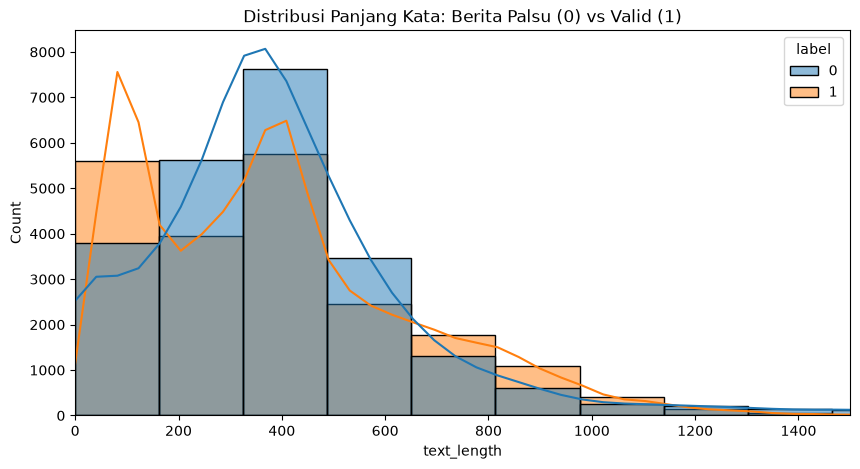

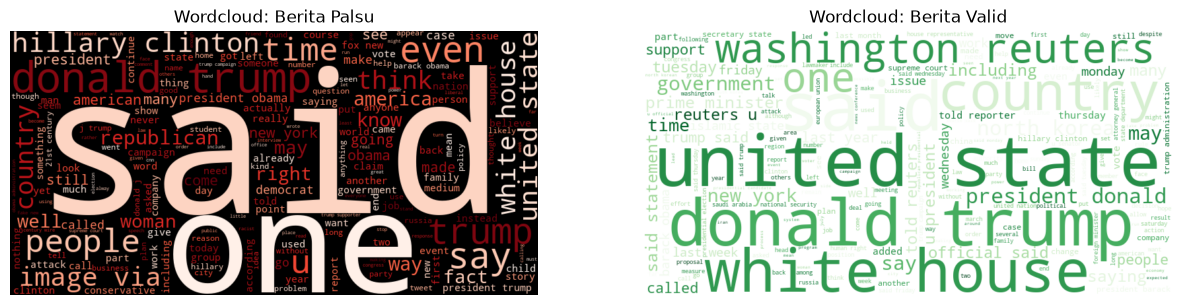

=== TOP 10 KATA - BERITA PALSU ===
trump: 73764
said: 31014
president: 26083
people: 26032
one: 23682
would: 23419
u: 22289
state: 21956
clinton: 18593
like: 18139

=== TOP 10 KATA - BERITA VALID ===
said: 97844
trump: 53752
u: 40682
state: 35954
would: 31164
reuters: 28110
president: 26707
republican: 21975
government: 19171
year: 18547

=== 15 KATA DENGAN BOBOT TF-IDF RATA-RATA TERTINGGI ===
trump: 0.07140
said: 0.05519
state: 0.03054
president: 0.03045
would: 0.02749
republican: 0.02574
people: 0.02441
clinton: 0.02377
obama: 0.02075
house: 0.02063
reuters: 0.02059
one: 0.02028
donald: 0.01929
year: 0.01911
new: 0.01894

=== RIWAYAT HASIL GRIDSEARCHCV ===
 param_C param_kernel param_gamma  mean_test_score  std_test_score  rank_test_score
    10.0          rbf       scale           0.9762        0.001851                1
     1.0          rbf       scale           0.9742        0.001693                2
     0.1          rbf       scale           0.9436        0.004349               

In [3]:
# ============================================
# BAGIAN 1: EDA - Distribusi Panjang Teks & Wordcloud
# ============================================
from wordcloud import WordCloud
import numpy as np
from collections import Counter

df_all['text_length'] = df_all['text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10,5))
sns.histplot(data=df_all, x='text_length', hue='label', bins=50, kde=True)
plt.title('Distribusi Panjang Kata: Berita Palsu (0) vs Valid (1)')
plt.xlim(0, 1500)
plt.savefig('distribusi_panjang_teks.png', dpi=150, bbox_inches='tight')
plt.show()

fake_text = " ".join(df_all[df_all['label'] == 0]['clean_text'].astype(str))
valid_text = " ".join(df_all[df_all['label'] == 1]['clean_text'].astype(str))

plt.figure(figsize=(15,7))
plt.subplot(1, 2, 1)
wordcloud_fake = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(fake_text)
plt.imshow(wordcloud_fake, interpolation='bilinear')
plt.title('Wordcloud: Berita Palsu')
plt.axis('off')

plt.subplot(1, 2, 2)
wordcloud_valid = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(valid_text)
plt.imshow(wordcloud_valid, interpolation='bilinear')
plt.title('Wordcloud: Berita Valid')
plt.axis('off')
plt.savefig('wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# BAGIAN 2: Tabel Top 10 Kata Terbanyak per Kelas
# ============================================
def top_words(text_series, n=10):
    words = " ".join(text_series.astype(str)).split()
    return Counter(words).most_common(n)

print("=== TOP 10 KATA - BERITA PALSU ===")
for word, count in top_words(df_all[df_all['label']==0]['clean_text']):
    print(f"{word}: {count}")

print("\n=== TOP 10 KATA - BERITA VALID ===")
for word, count in top_words(df_all[df_all['label']==1]['clean_text']):
    print(f"{word}: {count}")

# ============================================
# BAGIAN 3: Tabel 15 Bobot TF-IDF Tertinggi (rata-rata)
# ============================================
feature_names = tfidf.get_feature_names_out()
tfidf_means = np.asarray(X.mean(axis=0)).flatten()
top15_idx = tfidf_means.argsort()[-15:][::-1]

print("\n=== 15 KATA DENGAN BOBOT TF-IDF RATA-RATA TERTINGGI ===")
for idx in top15_idx:
    print(f"{feature_names[idx]}: {tfidf_means[idx]:.5f}")

# ============================================
# BAGIAN 4: Riwayat Lengkap GridSearchCV
# ============================================
print("\n=== RIWAYAT HASIL GRIDSEARCHCV ===")
cv_results = pd.DataFrame(grid.cv_results_)
cv_results_display = cv_results[['param_C', 'param_kernel', 'param_gamma', 'mean_test_score', 'std_test_score', 'rank_test_score']]
cv_results_display = cv_results_display.sort_values('rank_test_score')
print(cv_results_display.to_string(index=False))

# ============================================
# BAGIAN 5: Error Analysis - Ambil Sampel Prediksi Salah
# ============================================
test_indices = y_test.index

results_df = pd.DataFrame({
    'index': test_indices,
    'actual': y_test.values,
    'predicted': y_pred
})

errors_df = results_df[results_df['actual'] != results_df['predicted']]
print(f"\nTotal prediksi salah: {len(errors_df)} dari {len(results_df)} data uji")

false_negative = errors_df[(errors_df['actual'] == 0) & (errors_df['predicted'] == 1)]
false_positive = errors_df[(errors_df['actual'] == 1) & (errors_df['predicted'] == 0)]

print(f"Berita Palsu yang salah diprediksi sebagai Valid (False Negative): {len(false_negative)}")
print(f"Berita Valid yang salah diprediksi sebagai Fake (False Positive): {len(false_positive)}")

print("\n=== CONTOH KASUS: Berita Palsu yang lolos (diprediksi Valid) ===")
for idx in false_negative['index'].head(3):
    original_text = df_all.loc[idx, 'text']
    print(f"\n[Index {idx}] Panjang teks: {len(str(original_text).split())} kata")
    print(f"Cuplikan: {str(original_text)[:300]}...")

print("\n=== CONTOH KASUS: Berita Valid yang salah ditebak sebagai Palsu ===")
for idx in false_positive['index'].head(3):
    original_text = df_all.loc[idx, 'text']
    print(f"\n[Index {idx}] Panjang teks: {len(str(original_text).split())} kata")
    print(f"Cuplikan: {str(original_text)[:300]}...")

print(f"\n=== CONFUSION MATRIX FINAL ===")
print(f"True Negative (Fake benar): {cm[0][0]}")
print(f"False Positive (Fake→Valid): {cm[0][1]}")
print(f"False Negative (Valid→Fake): {cm[1][0]}")
print(f"True Positive (Valid benar): {cm[1][1]}")

In [4]:
# ============================================
# BAGIAN 6: Analisis Lanjutan - Pola pada False Negative
# ============================================

print("=== ANALISIS DETAIL: Berita Palsu yang Lolos (False Negative) ===\n")

for idx in false_negative['index'].head(5):
    original_text = df_all.loc[idx, 'text']
    clean_text_sample = df_all.loc[idx, 'clean_text']
    
    print(f"--- Index {idx} ---")
    print(f"Judul/awal teks asli: {str(original_text)[:150]}")
    print(f"Apakah mengandung 'Reuters': {'Reuters' in str(original_text)}")
    print(f"Apakah mengandung format kota+kurung (ex: WASHINGTON (Reuters)): {bool(re.search(r'[A-Z]{2,}\s*\(', str(original_text)[:50]))}")
    print(f"Panjang teks (kata): {len(str(original_text).split())}")
    print()

# Bandingkan rata-rata panjang teks: False Negative vs False Positive vs keseluruhan
print("=== PERBANDINGAN PANJANG TEKS ===")
fn_lengths = [len(str(df_all.loc[idx, 'text']).split()) for idx in false_negative['index']]
fp_lengths = [len(str(df_all.loc[idx, 'text']).split()) for idx in false_positive['index']]

print(f"Rata-rata panjang teks False Negative (Fake→Valid): {sum(fn_lengths)/len(fn_lengths):.1f} kata")
print(f"Rata-rata panjang teks False Positive (Valid→Fake): {sum(fp_lengths)/len(fp_lengths):.1f} kata")
print(f"Rata-rata panjang teks keseluruhan data uji: {df_all.loc[test_indices, 'text_length'].mean():.1f} kata")

# Cek proporsi False Negative yang mengandung kata 'Reuters' atau format kutipan lokasi
fn_texts = [str(df_all.loc[idx, 'text']) for idx in false_negative['index']]
fn_with_reuters = sum('Reuters' in t for t in fn_texts)
print(f"\nDari {len(fn_texts)} kasus False Negative, {fn_with_reuters} di antaranya mengandung kata 'Reuters'")

fp_texts = [str(df_all.loc[idx, 'text']) for idx in false_positive['index']]
fp_with_reuters = sum('Reuters' in t for t in fp_texts)
print(f"Dari {len(fp_texts)} kasus False Positive, {fp_with_reuters} di antaranya mengandung kata 'Reuters'")

=== ANALISIS DETAIL: Berita Palsu yang Lolos (False Negative) ===

--- Index 44060 ---
Judul/awal teks asli: This is a wake up call. Even though this isn t the main computer system, there are 100,000 people out there who re at risk now.Thieves used an online 
Apakah mengandung 'Reuters': False
Apakah mengandung format kota+kurung (ex: WASHINGTON (Reuters)): False
Panjang teks (kata): 232

--- Index 17049 ---
Judul/awal teks asli: Hollywood police spokeswoman Miranda Grossman said Thursday that the body of 37-year-old Beranton J. Whisenant Jr. was found early Wednesday by a pass
Apakah mengandung 'Reuters': False
Apakah mengandung format kota+kurung (ex: WASHINGTON (Reuters)): False
Panjang teks (kata): 414

--- Index 40060 ---
Judul/awal teks asli: PEACE THROUGH STRENGTH President Reagan showed President Trump the way Had a very good call last night with the President of China concerning the mena
Apakah mengandung 'Reuters': False
Apakah mengandung format kota+kurung (ex: WASHINGTON (R

Mengekstrak data N-Gram (Bigram & Trigram)...


C:\Users\restu\AppData\Local\Temp\ipykernel_17756\1853294008.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frekuensi', y='Frasa', data=df_fake_bigram, ax=axes[0], palette='Reds_r')
C:\Users\restu\AppData\Local\Temp\ipykernel_17756\1853294008.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frekuensi', y='Frasa', data=df_valid_bigram, ax=axes[1], palette='Greens_r')


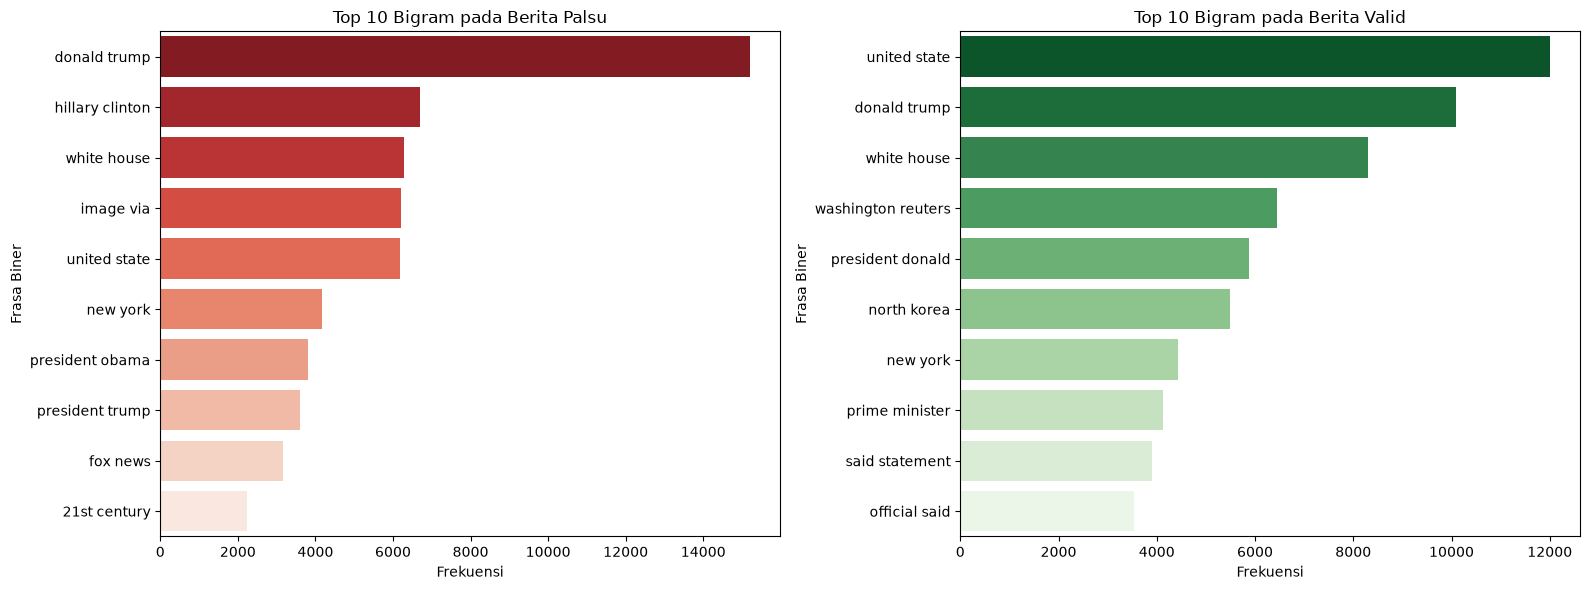

C:\Users\restu\AppData\Local\Temp\ipykernel_17756\1853294008.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frekuensi', y='Frasa', data=df_fake_trigram, ax=axes[0], palette='Reds_r')
C:\Users\restu\AppData\Local\Temp\ipykernel_17756\1853294008.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frekuensi', y='Frasa', data=df_valid_trigram, ax=axes[1], palette='Greens_r')


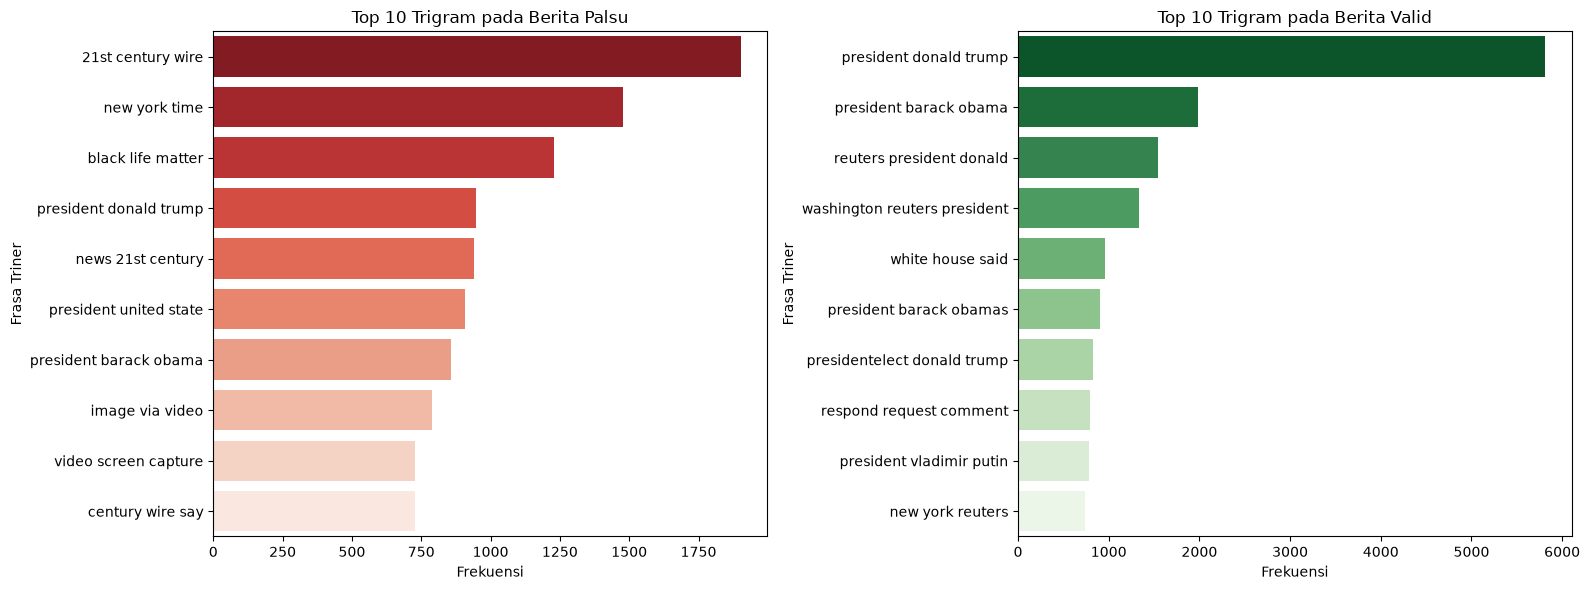


=== TOP 10 BIGRAM BERITA PALSU ===
          Frasa  Frekuensi
   donald trump      15218
hillary clinton       6689
    white house       6295
      image via       6194
   united state       6183
       new york       4181
president obama       3799
president trump       3614
       fox news       3172
   21st century       2229

=== TOP 10 BIGRAM BERITA VALID ===
             Frasa  Frekuensi
      united state      12015
      donald trump      10093
       white house       8309
washington reuters       6457
  president donald       5874
       north korea       5487
          new york       4432
    prime minister       4123
    said statement       3906
     official said       3532

=== TOP 10 TRIGRAM BERITA PALSU ===
                 Frasa  Frekuensi
     21st century wire       1902
         new york time       1478
     black life matter       1230
president donald trump        948
     news 21st century        941
president united state        907
president barack obama    

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

# ============================================
# BAGIAN EXTRA: Analisis N-Gram (Bigram & Trigram)
# ============================================

def get_top_ngram(corpus, ngram_range, n=10):
    """Fungsi untuk mengambil N-Gram teratas dari korpus teks"""
    vec = CountVectorizer(ngram_range=ngram_range).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return pd.DataFrame(words_freq[:n], columns=['Frasa', 'Frekuensi'])

# Memisahkan korpus clean_text berdasarkan kelas
clean_fake_corpus = df_all[df_all['label'] == 0]['clean_text'].astype(str)
clean_valid_corpus = df_all[df_all['label'] == 1]['clean_text'].astype(str)

print("Mengekstrak data N-Gram (Bigram & Trigram)...")
# Ekstraksi Bigram (2 kata)
df_fake_bigram = get_top_ngram(clean_fake_corpus, (2, 2), 10)
df_valid_bigram = get_top_ngram(clean_valid_corpus, (2, 2), 10)

# Ekstraksi Trigram (3 kata)
df_fake_trigram = get_top_ngram(clean_fake_corpus, (3, 3), 10)
df_valid_trigram = get_top_ngram(clean_valid_corpus, (3, 3), 10)

# --- VISUALISASI 1: PLOT BIGRAM ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x='Frekuensi', y='Frasa', data=df_fake_bigram, ax=axes[0], palette='Reds_r')
axes[0].set_title('Top 10 Bigram pada Berita Palsu')
axes[0].set_xlabel('Frekuensi')
axes[0].set_ylabel('Frasa Biner')

sns.barplot(x='Frekuensi', y='Frasa', data=df_valid_bigram, ax=axes[1], palette='Greens_r')
axes[1].set_title('Top 10 Bigram pada Berita Valid')
axes[1].set_xlabel('Frekuensi')
axes[1].set_ylabel('Frasa Biner')

plt.tight_layout()
plt.savefig('distribution_bigram.png', dpi=300, bbox_inches='tight')
plt.show()

# --- VISUALISASI 2: PLOT TRIGRAM ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x='Frekuensi', y='Frasa', data=df_fake_trigram, ax=axes[0], palette='Reds_r')
axes[0].set_title('Top 10 Trigram pada Berita Palsu')
axes[0].set_xlabel('Frekuensi')
axes[0].set_ylabel('Frasa Triner')

sns.barplot(x='Frekuensi', y='Frasa', data=df_valid_trigram, ax=axes[1], palette='Greens_r')
axes[1].set_title('Top 10 Trigram pada Berita Valid')
axes[1].set_xlabel('Frekuensi')
axes[1].set_ylabel('Frasa Triner')

plt.tight_layout()
plt.savefig('distribution_trigram.png', dpi=300, bbox_inches='tight')
plt.show()

# --- PRINT CONSOLE UNTUK MEMUDAHKAN PENYUSUNAN TABEL ---
print("\n=== TOP 10 BIGRAM BERITA PALSU ===")
print(df_fake_bigram.to_string(index=False))    

print("\n=== TOP 10 BIGRAM BERITA VALID ===")
print(df_valid_bigram.to_string(index=False))

print("\n=== TOP 10 TRIGRAM BERITA PALSU ===")
print(df_fake_trigram.to_string(index=False))

print("\n=== TOP 10 TRIGRAM BERITA VALID ===")
print(df_valid_trigram.to_string(index=False))